# Daily morning board

Run top → bottom after the CLI morning loop (`grade_projections`, `log_projections`, `odds_board`, `poll_odds open`).

1. **Yesterday** — graded `expected_K` vs actuals  
2. **Today** — preferred SP projections  
3. **Edges** — model × live DK/FD (`recommendations.parquet`)  
4. **CLV table** — open edge vs closing-line value  
5. **CLV stats** — skill-gate progress (mean CLV, bootstrap CI, n→100)  
6. **Season** — compact projection grades (+ optional residual charts)

Batting orders = RotoGrinders; dual SP rows collapse to **preferred** (MLB on disagreement).

In [14]:
from __future__ import annotations

import pickle
import subprocess
import sys
import tempfile
from datetime import date, datetime, timedelta
from pathlib import Path
from zoneinfo import ZoneInfo

import numpy as np
import polars as pl
from IPython.display import HTML, display

ROOT = Path.cwd().resolve()
if not (ROOT / "src" / "Python").exists():
    if (ROOT.parent / "src" / "Python").exists():
        ROOT = ROOT.parent.resolve()
    else:
        raise FileNotFoundError(f"Cannot find src/Python from cwd={Path.cwd()}")

sys.path.insert(0, str(ROOT / "src"))

WORKER = ROOT / "production" / "_notebook_score.py"
ALLOW_STALE = True
SLATE_DATE: date | None = None
QUIET_WARNINGS = True
ET = ZoneInfo("America/New_York")
TODAY = datetime.now(ET).date()
YESTERDAY = TODAY - timedelta(days=1)

GRADED_PATH = ROOT / "artifacts" / "projection_log" / "graded.parquet"
REC_PATH = ROOT / "artifacts" / "odds_log" / "recommendations.parquet"
LEDGER_PATH = ROOT / "artifacts" / "odds_log" / "ledger.parquet"


def _attach_pitcher_team(df: pl.DataFrame) -> pl.DataFrame:
    if "is_home" not in df.columns or "away_team" not in df.columns:
        return df
    return df.with_columns(
        pl.when(pl.col("is_home"))
        .then(pl.col("home_team"))
        .otherwise(pl.col("away_team"))
        .alias("pitcher_team"),
    )


def show_scrollable(df: pl.DataFrame, height: int = 420):
    pdf = df.to_pandas()
    table = pdf.to_html(index=False, classes="proj-board", na_rep="—")
    display(
        HTML(
            f"""
<style>
  .proj-scroll {{ max-height: {height}px; overflow: auto; border: 1px solid #4443; border-radius: 6px; }}
  .proj-scroll table.proj-board {{ border-collapse: collapse; width: max-content; min-width: 100%; font-size: 13px; }}
  .proj-scroll thead th {{ position: sticky; top: 0; background: var(--jp-layout-color1, #1e1e1e); z-index: 1; text-align: left; padding: 6px 10px; white-space: nowrap; }}
  .proj-scroll tbody td {{ text-align: left; padding: 4px 10px; white-space: nowrap; }}
</style>
<div class="proj-scroll">{table}</div>
"""
        )
    )


def _summary(df: pl.DataFrame, label: str) -> dict:
    if df.is_empty():
        return {"label": label, "n": 0}
    ek = df["expected_K"].to_numpy()
    ak = df["actual_K"].to_numpy()
    resid = ek - ak
    return {
        "label": label,
        "n": int(df.height),
        "mae_K": round(float(np.mean(np.abs(resid))), 3),
        "bias_K": round(float(np.mean(resid)), 3),
        "rmse_K": round(float(np.sqrt(np.mean(resid**2))), 3),
        "corr": round(float(np.corrcoef(ek, ak)[0, 1]), 3) if len(ek) > 1 else None,
        "within_1K": round(float(np.mean(np.abs(resid) <= 1.0)), 3),
    }


print("repo:", ROOT)
print("today ET:", TODAY, "| yesterday ET:", YESTERDAY)

repo: C:\Users\ckaplinger\Downloads\Personal-Projects\MLB-Props
today ET: 2026-07-31 | yesterday ET: 2026-07-30


## 1. Score today's slate

Needed for today's projections below. Quiet worker subprocess.

In [15]:
with tempfile.NamedTemporaryFile(suffix=".pkl", delete=False) as tmp:
    out_path = Path(tmp.name)

cmd = [sys.executable, str(WORKER), str(out_path)]
if ALLOW_STALE:
    cmd.append("--allow-stale")
if SLATE_DATE is not None:
    cmd.extend(["--date", SLATE_DATE.isoformat()])
if QUIET_WARNINGS:
    cmd.append("--quiet")

proc = subprocess.run(cmd, cwd=str(ROOT), capture_output=True, text=True)
if proc.returncode != 0:
    raise RuntimeError(
        "Board scorer failed.\n"
        f"cmd: {' '.join(cmd)}\nstdout:\n{proc.stdout}\nstderr:\n{proc.stderr}"
    )

payload = pickle.loads(out_path.read_bytes())
out_path.unlink(missing_ok=True)

board: pl.DataFrame = payload["board"]
preferred: pl.DataFrame = payload["preferred"]
build_meta = payload["build_meta"]
report = payload["report"]
slate_date = str(build_meta.get("slate_date"))

print(
    "slate:", slate_date,
    "| preferred:", preferred.height,
    "| mean xK:", round(float(report["mean_expected_K"]), 3),
)
print("rolling_max:", build_meta.get("rolling_max_date"), "stale_days:", build_meta.get("stale_days"))

slate: 2026-07-31 | preferred: 30 | mean xK: 4.89
rolling_max: 2026-07-30 stale_days: 1


## 2. Yesterday — projections vs actuals

From `graded.parquet`. Excludes pregame OOS and abbreviated outings when those flags exist.

`residual_K = expected_K − actual_K` (positive = over-projected).

In [16]:
matched = pl.DataFrame()
prev_day = pl.DataFrame()
if not GRADED_PATH.exists():
    print(f"Missing {GRADED_PATH}. Run grade_projections after Level 1 has actuals.")
else:
    graded = pl.read_parquet(GRADED_PATH).with_columns(pl.col("game_date").cast(pl.Date))
    if "is_preferred" in graded.columns:
        graded = graded.filter(pl.col("is_preferred"))
    if "grade_preferred_only" in graded.columns:
        pref_g = graded.filter(pl.col("grade_preferred_only") == True)  # noqa: E712
        if pref_g.height:
            graded = pref_g
    if "is_out_of_support" in graded.columns:
        graded = graded.filter(~pl.col("is_out_of_support").fill_null(False))
    if "is_abbreviated_outing" in graded.columns:
        graded = graded.filter(~pl.col("is_abbreviated_outing").fill_null(False))
    matched = graded.filter(pl.col("has_actual") & pl.col("actual_K").is_not_null())
    prev_day = matched.filter(pl.col("game_date") == YESTERDAY)

    display(pl.DataFrame([_summary(prev_day, f"yesterday_{YESTERDAY}")]).to_pandas())
    if prev_day.is_empty():
        print(f"No graded actuals for {YESTERDAY} yet.")
    else:
        prev = prev_day
        if "pitcher_team" not in prev.columns:
            prev = _attach_pitcher_team(prev)
        gcols = [
            c
            for c in (
                "player_name",
                "pitcher_team",
                "away_team",
                "home_team",
                "expected_K",
                "actual_K",
                "residual_K",
                "projected_tbf",
                "actual_PA",
            )
            if c in prev.columns
        ]
        prev = (
            prev.select(gcols)
            .with_columns(
                [
                    pl.col(c).round(2)
                    for c in ("expected_K", "residual_K", "projected_tbf")
                    if c in prev.columns
                ]
            )
            .sort("residual_K")
        )
        show_scrollable(prev, height=320)

,label,n,mae_K,bias_K,rmse_K,corr,within_1K
0,yesterday_2026-07-30,16,1.725,-0.36,2.01,0.301,0.25


player_name,pitcher_team,away_team,home_team,expected_K,actual_K,residual_K,projected_tbf,actual_PA
Sean Burke,CWS,NYY,CWS,6.40,10.0,-3.60,23.95,23.0
Bryan Woo,SEA,SEA,LAD,5.18,8.0,-2.82,23.87,22.0
Javier Assad,CHC,CHC,STL,3.31,6.0,-2.69,19.14,20.0
Noah Cameron,KC,KC,MIN,4.43,7.0,-2.57,23.02,26.0
Robbie Ray,SF,SF,SD,4.86,6.0,-1.14,23.98,22.0
Roki Sasaki,LAD,SEA,LAD,5.86,7.0,-1.14,22.52,24.0
Rhett Lowder,CIN,PIT,CIN,3.94,5.0,-1.06,23.39,23.0
Nolan McLean,NYM,MIA,NYM,5.18,6.0,-0.82,24.13,26.0
Eury Perez,MIA,MIA,NYM,5.46,6.0,-0.54,22.62,24.0
Sonny Gray,BOS,BOS,ATH,4.70,5.0,-0.30,23.96,30.0


## 3. Today — preferred projections

`pitcher_team`, name, matchup, `xK`, and over-line probabilities.

In [17]:
pref = _attach_pitcher_team(preferred)
p_cols = [c for c in pref.columns if c.startswith("p_over_")]
front = [
    c
    for c in ("pitcher_team", "player_name", "away_team", "home_team", "expected_K")
    if c in pref.columns
]

round_exprs = [pl.col(c).round(3) for c in p_cols if pref[c].dtype in (pl.Float32, pl.Float64)]
if "expected_K" in pref.columns:
    round_exprs.append(pl.col("expected_K").round(2))

today_view = (
    pref.select(front + p_cols)
    .sort("expected_K", descending=True)
    .with_columns(round_exprs)
)
show_scrollable(today_view, height=480)

pitcher_team,player_name,away_team,home_team,expected_K,p_over_2_5,p_over_3_5,p_over_4_5,p_over_5_5,p_over_6_5,p_over_7_5,p_over_8_5,p_over_9_5
CIN,Hunter Greene,PIT,CIN,7.03,0.986,0.951,0.876,0.750,0.585,0.408,0.252,0.137
TOR,Dylan Cease,STL,TOR,6.68,0.980,0.934,0.841,0.697,0.521,0.346,0.202,0.103
MIL,Shane Drohan,MIL,LAA,6.48,0.978,0.930,0.832,0.683,0.503,0.328,0.187,0.093
CHC,Shota Imanaga,NYY,CHC,6.03,0.964,0.895,0.770,0.599,0.414,0.252,0.133,0.061
NYM,Freddy Peralta,MIA,NYM,6.02,0.962,0.889,0.759,0.586,0.400,0.240,0.126,0.057
HOU,Hunter Brown,TEX,HOU,5.90,0.958,0.879,0.743,0.564,0.377,0.220,0.112,0.049
TEX,Nathan Eovaldi,TEX,HOU,5.88,0.956,0.875,0.736,0.557,0.372,0.217,0.110,0.049
PIT,Paul Skenes,PIT,CIN,5.80,0.951,0.863,0.717,0.532,0.346,0.196,0.096,0.041
SEA,Bryce Miller,MIN,SEA,5.57,0.946,0.853,0.701,0.513,0.329,0.183,0.088,0.037
TB,Nick Martinez,CWS,TB,5.43,0.935,0.829,0.666,0.474,0.295,0.160,0.075,0.030


## 4. Today — edges (model × books)

Reads `artifacts/odds_log/recommendations.parquet` from `production/odds_board.py`.
Shows **BET** rows (≥8%, in-support) by default.

In [18]:
SHOW_ALL_EDGES = False  # True → include skip / OOS

if not REC_PATH.exists():
    print(f"Missing {REC_PATH}. Run: python production/odds_board.py --unit 50")
else:
    rec = pl.read_parquet(REC_PATH)
    if "game_date" in rec.columns:
        rec = rec.with_columns(pl.col("game_date").cast(pl.Utf8).str.slice(0, 10).alias("game_date"))
        rec = rec.filter(pl.col("game_date") == slate_date[:10])
    if not SHOW_ALL_EDGES and "recommendation" in rec.columns:
        edges = rec.filter(pl.col("recommendation") == "BET")
    else:
        edges = rec
    edge_cols = [
        c
        for c in (
            "recommendation",
            "pitcher_team",
            "player_name",
            "expected_K",
            "book",
            "line",
            "best_side",
            "best_price",
            "edge",
            "units",
            "stake",
            "oos_reason",
        )
        if c in edges.columns
    ]
    view = edges.select(edge_cols)
    if "edge" in view.columns:
        view = view.with_columns((pl.col("edge") * 100).round(1).alias("edge_pct")).drop("edge")
    if "expected_K" in view.columns:
        view = view.with_columns(pl.col("expected_K").round(2))
    if view.is_empty():
        print("No BET rows for this slate (or empty recommendations).")
    else:
        show_scrollable(view, height=360)
    print(f"recommendations n={rec.height} shown={view.height if not view.is_empty() else 0}")

recommendation,pitcher_team,player_name,expected_K,book,line,best_side,best_price,units,stake,oos_reason,edge_pct
BET,PIT,Paul Skenes,5.77,draftkings,7.5,under,110.0,3.78,188.77,None,36.0
BET,TB,Nick Martinez,5.43,fanduel,4.5,over,118.0,2.28,114.19,None,23.3
BET,CWS,Erick Fedde,4.18,fanduel,3.5,over,132.0,2.04,101.86,None,21.9
BET,TOR,Dylan Cease,6.68,draftkings,7.5,under,111.0,2.04,101.81,None,20.6
BET,LAA,Ryan Johnson,4.98,draftkings,4.5,over,127.0,1.51,75.41,None,16.6
BET,MIL,Shane Drohan,6.48,fanduel,5.5,over,-128.0,1.65,82.50,None,15.4
BET,CLE,Tanner Bibee,3.93,draftkings,4.5,under,-116.0,1.55,77.70,None,15.2
BET,NYM,Freddy Peralta,6.02,draftkings,5.5,over,117.0,1.38,68.87,None,15.0
BET,MIA,Janson Junk,4.63,draftkings,3.5,over,-157.0,1.47,73.49,None,13.0
BET,SF,Carson Whisenhunt,4.55,draftkings,3.5,over,-152.0,1.27,63.58,None,11.9


recommendations n=25 shown=14


## 5. Model edge vs CLV

Paper ledger (`poll_odds` open → close watcher → settle).

- **edge_pct** — model edge at open (what you thought you had)
- **clv_pct** — close market prob − bet-time market prob on the bet side (positive = beat the close)

**Per-book detail** (DK and FD both shown when logged). Skill stats in §6 dedupe to one ticket per prop.

Morning default = **yesterday + today's slate**. Set `CLV_DATES = None` for the full ledger, or a single ISO date string.


In [19]:
# Morning default: yesterday + today. Examples:
#   CLV_DATES = "2026-07-30"          # one day
#   CLV_DATES = None                  # entire ledger
#   CLV_DATES = ["2026-07-29", "2026-07-30"]
CLV_DATES: str | list[str] | None = [YESTERDAY.isoformat(), slate_date[:10]]
BETS_ONLY_CLV = False  # True → passes_floor only
HIGHLIGHT: str | None = None  # e.g. "McClanahan" to filter name substring

if not LEDGER_PATH.exists():
    print(f"Missing {LEDGER_PATH}. Run poll_odds --snapshot open.")
else:
    led = pl.read_parquet(LEDGER_PATH)
    if "game_date" in led.columns:
        led = led.with_columns(pl.col("game_date").cast(pl.Utf8).str.slice(0, 10).alias("d"))
    else:
        led = led.with_columns(pl.lit("").alias("d"))

    if isinstance(CLV_DATES, str):
        led = led.filter(pl.col("d") == CLV_DATES[:10])
    elif isinstance(CLV_DATES, list):
        days = [d[:10] for d in CLV_DATES]
        led = led.filter(pl.col("d").is_in(days))

    if BETS_ONLY_CLV and "passes_floor" in led.columns:
        led = led.filter(pl.col("passes_floor") == True)  # noqa: E712
    if HIGHLIGHT and "player_name" in led.columns:
        led = led.filter(pl.col("player_name").str.contains(f"(?i){HIGHLIGHT}"))

    # Attach graded actual / expected K when available
    if GRADED_PATH.exists() and "pitcher" in led.columns:
        g = (
            pl.read_parquet(GRADED_PATH)
            .with_columns(
                pl.col("game_date").cast(pl.Utf8).str.slice(0, 10).alias("d"),
                pl.col("pitcher").cast(pl.Int64),
            )
            .select(["d", "pitcher", "actual_K", "expected_K"])
            .unique(subset=["d", "pitcher"], keep="first")
        )
        led = led.with_columns(pl.col("pitcher").cast(pl.Int64, strict=False)).join(
            g, on=["d", "pitcher"], how="left", suffix="_graded"
        )

    cols = [
        c
        for c in (
            "d",
            "player_name",
            "book",
            "side",
            "line",
            "bet_price",
            "edge",
            "passes_floor",
            "units",
            "close_over",
            "close_under",
            "clv_pp",
            "close_status",
            "expected_K",
            "actual_K",
            "result",
            "pnl",
            "status",
        )
        if c in led.columns
    ]
    view = led.select(cols)
    if "edge" in view.columns:
        view = view.with_columns((pl.col("edge") * 100).round(1).alias("edge_pct")).drop("edge")
    if "clv_pp" in view.columns:
        view = view.with_columns((pl.col("clv_pp") * 100).round(2).alias("clv_pct")).drop("clv_pp")
    for c in ("expected_K", "units", "pnl"):
        if c in view.columns:
            # all-null cols come through as Null dtype; cast before round
            view = view.with_columns(pl.col(c).cast(pl.Float64, strict=False).round(2))

    # Put the comparison columns up front when present
    front = [
        c
        for c in (
            "d",
            "player_name",
            "book",
            "side",
            "line",
            "bet_price",
            "edge_pct",
            "clv_pct",
            "passes_floor",
            "close_status",
            "units",
            "expected_K",
            "actual_K",
            "result",
            "pnl",
            "status",
            "close_over",
            "close_under",
        )
        if c in view.columns
    ]
    view = view.select(front)

    sort_keys = [k for k in ("d", "passes_floor", "clv_pct", "edge_pct") if k in view.columns]
    if sort_keys:
        desc = [k in ("passes_floor", "clv_pct", "edge_pct") for k in sort_keys]
        view = view.sort(sort_keys, descending=desc)

    if view.is_empty():
        print(f"No ledger rows for {CLV_DATES or 'all dates'}.")
    else:
        show_scrollable(view, height=420)
        if "clv_pct" in view.columns:
            clvs = [x for x in view["clv_pct"].to_list() if x is not None]
            print(f"n={view.height} tickets (per-book)  with_clv={len(clvs)}", end="")
            if clvs:
                print(f"  mean_clv_pct={sum(clvs) / len(clvs):+.2f}")
                print("(per-book raw mean — skill stats dedupe in §6)")
            else:
                print()
        if "pnl" in view.columns and "status" in view.columns:
            settled = view.filter(pl.col("status") == "settled")
            if settled.height:
                total = settled["pnl"].sum()
                if total is not None:
                    print(f"settled_pnl_sum=${float(total):+.2f}")

d,player_name,book,side,line,bet_price,edge_pct,clv_pct,passes_floor,close_status,units,expected_K,actual_K,result,pnl,status,close_over,close_under
2026-07-30,Roki Sasaki,fanduel,over,5.5,100.0,10.6,5.28,True,ok,0.92,5.86,7.0,None,—,open,-125.0,-102.0
2026-07-30,JP Sears,fanduel,over,3.5,-102.0,18.2,3.22,True,ok_cross_book,1.84,4.44,2.0,None,—,open,-117.0,-109.0
2026-07-30,Rhett Lowder,fanduel,under,4.5,114.0,21.6,2.64,True,ok,2.12,3.94,5.0,None,—,open,-130.0,102.0
2026-07-30,Robbie Ray,fanduel,over,4.5,102.0,8.7,2.06,True,ok_cross_book,0.69,4.86,6.0,None,—,open,-107.0,-119.0
2026-07-30,Sean Burke,draftkings,under,7.5,-126.0,17.5,0.71,True,ok_cross_book,1.93,6.40,10.0,None,—,open,102.0,-130.0
2026-07-30,Sean Burke,fanduel,under,7.5,-130.0,16.8,0.00,True,ok,1.86,6.40,10.0,None,—,open,102.0,-130.0
2026-07-30,Bailey Ober,fanduel,over,3.5,-162.0,15.1,0.00,True,—,1.81,4.82,3.0,None,—,open,-162.0,126.0
2026-07-30,Grant Holmes,fanduel,under,4.5,-140.0,8.4,-0.39,True,ok,0.74,4.01,4.0,None,—,open,108.0,-138.0
2026-07-30,Nolan McLean,fanduel,under,6.5,-130.0,22.3,-2.89,True,ok,2.61,5.18,6.0,None,—,open,-111.0,-115.0
2026-07-30,Ryan Weathers,fanduel,over,5.5,-158.0,15.1,-11.15,True,ok,1.79,6.93,4.0,None,—,open,102.0,-130.0


n=64 tickets (per-book)  with_clv=18  mean_clv_pct=-0.29
(per-book raw mean — skill stats dedupe in §6)


## 6. CLV skill tracker

Running ledger stats against the pre-registered gate in `docs/reference/market_clv_gates.md`:

- **Skill bar:** mean `CLV_pp > 0` with bootstrap CI excluding 0
- **Min sample:** n ≥ 100 **props** with CLV before judgment (BET + skip both count)
- **No double count:** one ticket per `(date, pitcher, line)` — keeps the best-edge book (same rule as `odds_board`)

Uses the **full ledger** (not just yesterday/today). Re-run after close watcher / settle.


,cohort,n_props,n_clv,mean_clv_pct,ci_lo_pct,ci_hi_pct,gate,pct_to_min_n
0,all_props,40,16,-0.271,-2.212,1.374,building_sample,16.0
1,BET_only_edge>=8%,23,9,-0.057,-3.433,2.489,building_sample,9.0


ledger tickets=64 → props=40 (deduped best-edge book)  with_clv=16  BET=23  BET_with_clv=9
status (deduped):


,status,count
0,open,40


close_status (deduped):


,close_status,count
0,NaN,27
1,ok,10
2,ok_cross_book,3


threshold curve: need ≥10 settled props (have 0)


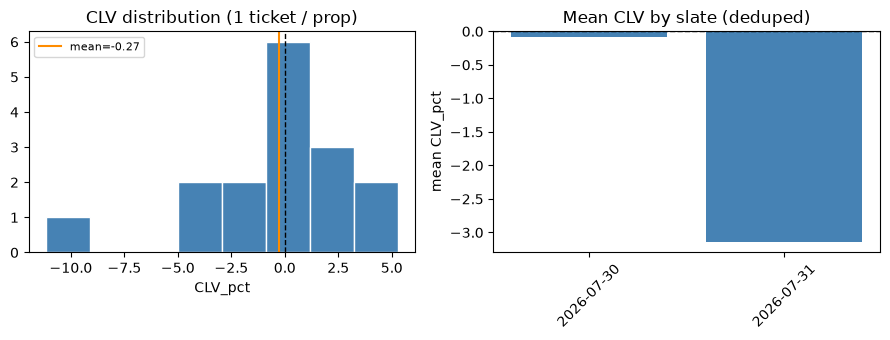

In [20]:
from Python.market import bootstrap_mean_ci, DEFAULT_EDGE_FLOOR
from Python.odds_ledger import dedupe_ledger_props, run_threshold_curve, settled_bets

MIN_CLV_N = 100  # skill-gate sample size from market_clv_gates.md

if not LEDGER_PATH.exists():
    print(f"Missing {LEDGER_PATH}.")
else:
    full_raw = pl.read_parquet(LEDGER_PATH)
    # Skill / charts: one prop per (date, pitcher, line) — best-edge book
    full = dedupe_ledger_props(full_raw)
    n_raw, n_props = full_raw.height, full.height
    status_counts = (
        full["status"].value_counts().sort("status")
        if "status" in full.columns and n_props
        else pl.DataFrame()
    )
    close_counts = (
        full["close_status"].value_counts().sort("close_status")
        if "close_status" in full.columns and n_props
        else pl.DataFrame()
    )

    with_clv = full.filter(pl.col("clv_pp").is_not_null()) if "clv_pp" in full.columns else pl.DataFrame()
    bets = (
        full.filter(pl.col("passes_floor") == True)  # noqa: E712
        if "passes_floor" in full.columns
        else pl.DataFrame()
    )

    def _clv_block(df: pl.DataFrame, label: str) -> dict:
        n_tickets = int(df.height) if not df.is_empty() else 0
        vals: list[float] = []
        if not df.is_empty() and "clv_pp" in df.columns:
            vals = [float(x) for x in df["clv_pp"].to_list() if x is not None]
        n_clv = len(vals)
        row: dict = {
            "cohort": label,
            "n_props": n_tickets,
            "n_clv": n_clv,
            "mean_clv_pct": None,
            "ci_lo_pct": None,
            "ci_hi_pct": None,
            "gate": "insufficient_n",
            "pct_to_min_n": round(100.0 * min(n_clv, MIN_CLV_N) / MIN_CLV_N, 1),
        }
        if n_clv >= 5:
            m, lo, hi = bootstrap_mean_ci(vals)
            row["mean_clv_pct"] = round(m * 100, 3)
            row["ci_lo_pct"] = round(lo * 100, 3)
            row["ci_hi_pct"] = round(hi * 100, 3)
            if n_clv < MIN_CLV_N:
                row["gate"] = "building_sample"
            elif lo > 0:
                row["gate"] = "PASS"
            elif hi < 0:
                row["gate"] = "FAIL"
            else:
                row["gate"] = "INCONCLUSIVE"
        return row

    stats = pl.DataFrame(
        [
            _clv_block(full, "all_props"),
            _clv_block(bets, f"BET_only_edge>={DEFAULT_EDGE_FLOOR:.0%}"),
        ]
    )
    display(stats.to_pandas())

    bets_clv_n = 0
    if bets.height and "clv_pp" in bets.columns:
        bets_clv_n = bets.filter(pl.col("clv_pp").is_not_null()).height
    print(
        f"ledger tickets={n_raw} → props={n_props} (deduped best-edge book)  "
        f"with_clv={with_clv.height}  BET={bets.height}  BET_with_clv={bets_clv_n}"
    )
    if not status_counts.is_empty():
        print("status (deduped):")
        display(status_counts.to_pandas())
    if not close_counts.is_empty():
        print("close_status (deduped):")
        display(close_counts.to_pandas())

    settled = settled_bets(full)
    if settled.height and "pnl" in settled.columns:
        total = settled["pnl"].cast(pl.Float64, strict=False).sum()
        if total is not None:
            print(f"settled_props={settled.height}  total_pnl=${float(total):+.2f}")

    if settled.height >= 10:
        curve = run_threshold_curve(full_raw, write=False)  # dedupes inside
        if not curve.is_empty():
            exprs = [(pl.col("edge_floor") * 100).round(0).alias("floor_pct")]
            if "mean_clv_pp" in curve.columns:
                exprs.append((pl.col("mean_clv_pp") * 100).round(2).alias("mean_clv_pct"))
            show = curve.with_columns(exprs)
            keep = [c for c in ("floor_pct", "n", "stake_sum", "roi", "mean_clv_pct") if c in show.columns]
            print("threshold curve (exploratory — do not retune 8% from this alone):")
            show_scrollable(show.select(keep), height=260)
    else:
        print(f"threshold curve: need ≥10 settled props (have {settled.height})")

    if with_clv.height >= 3:
        import matplotlib.pyplot as plt

        clv_pct = (with_clv["clv_pp"] * 100).to_numpy()
        fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
        ax = axes[0]
        ax.hist(clv_pct, bins=min(12, max(4, with_clv.height // 2)), color="steelblue", edgecolor="white")
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.axvline(float(clv_pct.mean()), color="darkorange", linewidth=1.5, label=f"mean={clv_pct.mean():+.2f}")
        ax.set_xlabel("CLV_pct")
        ax.set_title("CLV distribution (1 ticket / prop)")
        ax.legend(fontsize=8)
        ax = axes[1]
        by_day = (
            with_clv.with_columns(pl.col("game_date").cast(pl.Utf8).str.slice(0, 10).alias("d"))
            .group_by("d")
            .agg(pl.col("clv_pp").mean().alias("mean_clv"), pl.len().alias("n"))
            .sort("d")
        )
        if by_day.height:
            ax.bar(by_day["d"].to_list(), (by_day["mean_clv"] * 100).to_list(), color="steelblue")
            ax.axhline(0, color="black", linestyle="--", linewidth=1)
            ax.set_ylabel("mean CLV_pct")
            ax.set_title("Mean CLV by slate (deduped)")
            ax.tick_params(axis="x", rotation=45)
        fig.tight_layout()
        plt.show()
    else:
        print("CLV charts: need ≥3 closes filled on deduped props.")


## 7. Season so far (compact)

Preferred graded starts with actuals — summary + per-date MAE only.

In [21]:
if matched.is_empty():
    print("No matched graded starts yet.")
else:
    display(pl.DataFrame([_summary(matched, "all_logged")]).to_pandas())
    by_date = (
        matched.group_by("game_date")
        .agg(
            pl.len().alias("n"),
            pl.col("residual_K").abs().mean().alias("mae_K"),
            pl.col("residual_K").mean().alias("bias_K"),
        )
        .sort("game_date")
        .with_columns(pl.col("mae_K").round(3), pl.col("bias_K").round(3))
    )
    show_scrollable(by_date, height=220)

,label,n,mae_K,bias_K,rmse_K,corr,within_1K
0,all_logged,72,1.845,-0.021,2.213,0.444,0.292


game_date,n,mae_K,bias_K
2026-07-28,29,2.231,0.156
2026-07-29,27,1.501,-0.012
2026-07-30,16,1.725,-0.360


## 8. Projection residual charts (optional)

Model calibration only — not needed for morning edges/CLV. Skip unless you want predicted-vs-actual / residual shape.

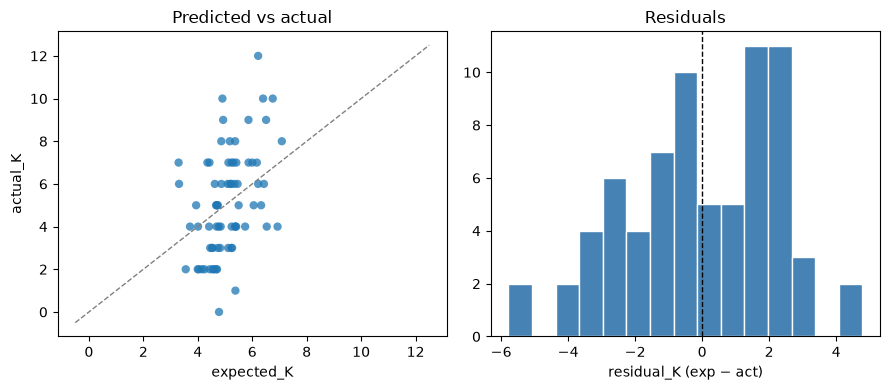

In [22]:
import matplotlib.pyplot as plt

if matched.height < 2:
    print("Need ≥2 matched starts for charts.")
else:
    pdf = matched.select("expected_K", "actual_K", "residual_K").to_pandas()
    ek, ak, resid = pdf["expected_K"].to_numpy(), pdf["actual_K"].to_numpy(), pdf["residual_K"].to_numpy()
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    ax = axes[0]
    ax.scatter(ek, ak, alpha=0.75, edgecolors="none")
    lo, hi = float(min(ek.min(), ak.min()) - 0.5), float(max(ek.max(), ak.max()) + 0.5)
    ax.plot([lo, hi], [lo, hi], "--", color="gray", linewidth=1)
    ax.set_xlabel("expected_K")
    ax.set_ylabel("actual_K")
    ax.set_title("Predicted vs actual")
    ax = axes[1]
    ax.hist(resid, bins=min(15, max(5, matched.height // 2)), color="steelblue", edgecolor="white")
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("residual_K (exp − act)")
    ax.set_title("Residuals")
    fig.tight_layout()
    plt.show()